# 📘 Notebook: Customer Descriptive Analysis (R&D Phase)
1. Markdown: Project Initiation

# 📊 Project 03: Customer Descriptive Analysis & Data Auditing
**Role:** Principal Marketing Data Analyst (MDA) Specialist  
**Context:** Brazilian E-commerce (Olist) - RFM Foundation  

---

## 🎯 Objektif Bisnis
Melakukan eksplorasi mendalam (Deep-Dive) terhadap distribusi Recency, Frequency, dan Monetary untuk:
1. Mendeteksi pelanggan **'Whale'** (High-Value Outliers).
2. Memvalidasi korelasi antar variabel marketing.
3. Membangun **Baseline Segmentasi** sebelum tahap Automation Machine Learning.

2. Code: Environment Setup & Data Loading

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Platinum Visualization Setup
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

def find_project_root(marker='models'):
    current_path = Path.cwd()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists(): return parent
    return current_path

# Path Management
root = find_project_root()
input_path = root / "data" / "production" / "customer_rfm" / "01_customer_rfm_ready_to_model.parquet"

# Load validated data from Descriptive Phase
df_rfm = pd.read_parquet(input_path)
print(f"✅ Data Ready for Diagnosis: {len(df_rfm):,} Customers")
df_rfm.head()

✅ Data Ready for Diagnosis: 93,345 Customers


,customer_unique_id,recency,frequency,monetary,R_Score,F_Score,M_Score
0,4d34eb7a11a201d8a2317a791adbcb29,552,1,218.13,1,1,4
1,f209aeff5575256eaa8352abab984ce8,154,1,112.38,4,1,3
2,2d8898fb1310c4e23f64fc23d6760794,221,1,57.72,3,1,2
3,be6785c7350c0f5bda4067f160f29d59,288,1,21.77,2,1,1
4,07212b6b20c842faac31170b9dfd66e6,479,1,256.43,1,1,5


3. Code: Multivariate Correlation Diagnosis

🔍 Mendiagnosa Hubungan Antar Variabel (Spearman Rank)...


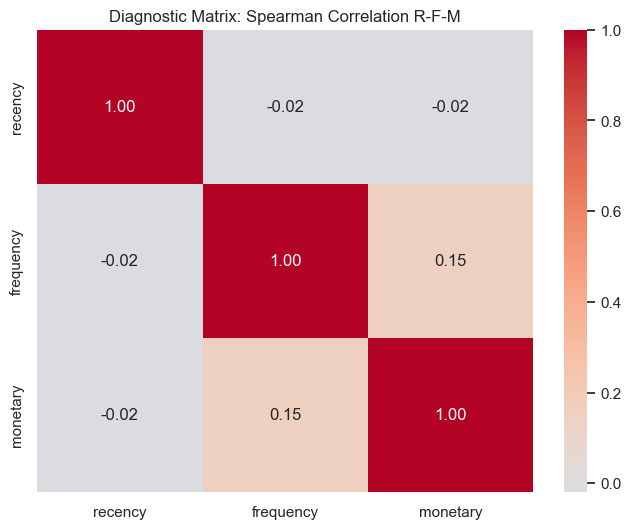

In [8]:
# 1. MULTIVARIATE CORRELATION DIAGNOSIS
print("🔍 Mendiagnosa Hubungan Antar Variabel (Spearman Rank)...")

# Spearman dipilih karena data E-commerce Olist terbukti tidak berdistribusi normal (skewed).
corr_matrix = df_rfm[['recency', 'frequency', 'monetary']].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Diagnostic Matrix: Spearman Correlation R-F-M")
plt.show()

# Insight MDA: Korelasi kuat antara F dan M menunjukkan loyalitas kunjungan berbanding lurus dengan nilai ekonomi.

4. Code: Distribution Skewness Treatment

🧪 Menjalankan Terapi Distribusi pada Variabel Skewed...


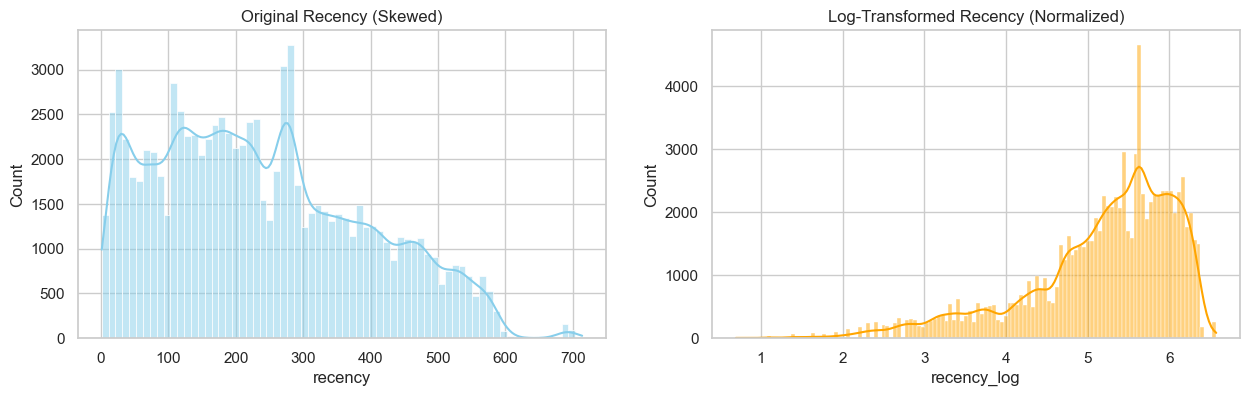

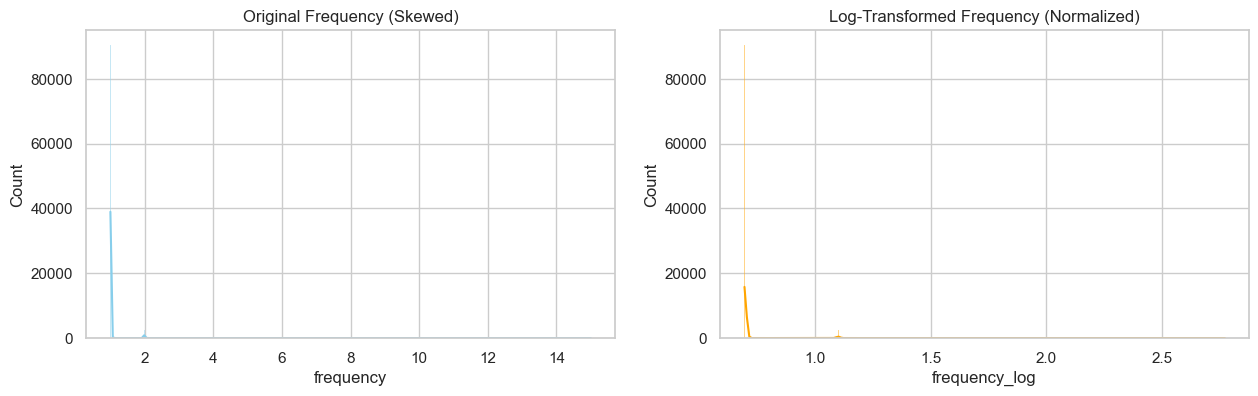

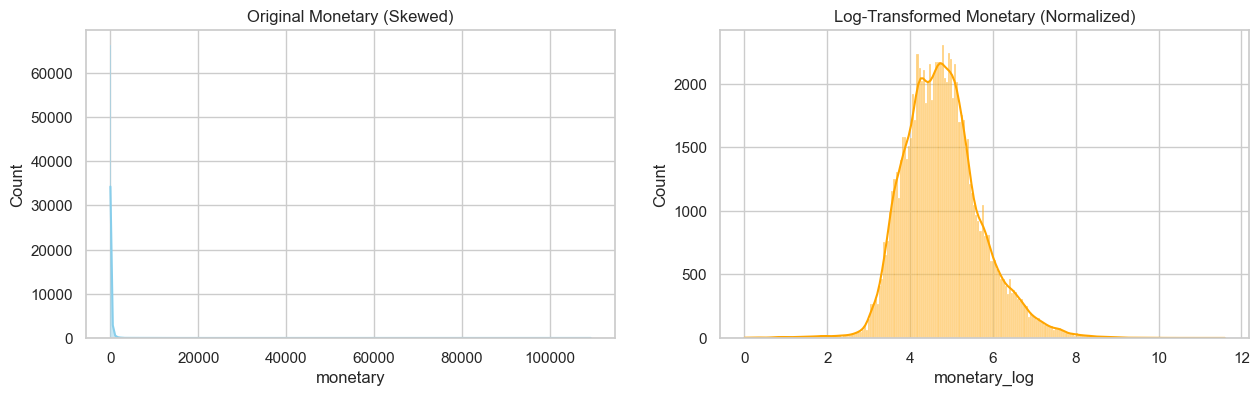

In [9]:
# 2. DISTRIBUTION SKEWNESS TREATMENT (Log Transformation)
print("🧪 Menjalankan Terapi Distribusi pada Variabel Skewed...")

df_diag = df_rfm.copy()

# Melakukan Log Transformation untuk menekan dampak outlier ekstrem.
for col in ['recency', 'frequency', 'monetary']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    # Original Distribution
    sns.histplot(df_rfm[col], kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"Original {col.capitalize()} (Skewed)")
    
    # Log Transformed
    df_diag[f'{col}_log'] = np.log1p(df_rfm[col]) # log1p untuk menghindari error pada nilai 0
    sns.histplot(df_diag[f'{col}_log'], kde=True, ax=axes[1], color="orange")
    axes[1].set_title(f"Log-Transformed {col.capitalize()} (Normalized)")
    
    plt.show()

# Insight MDA: Transformasi ini wajib dilakukan agar algoritma K-Means dapat menghitung jarak Euclidean secara adil.

5. Code: Feature Scaling & Persistence

In [13]:
# 3. FEATURE SCALING (Standardization)
print("📏 Melakukan Standarisasi Fitur (Z-Score Scaling)...")

# Memilih fitur yang sudah di-log
features_to_scale = ['recency_log', 'frequency_log', 'monetary_log']
scaler = StandardScaler()

# Scaling agar mean = 0 dan std = 1.
scaled_data = scaler.fit_transform(df_diag[features_to_scale])
df_final = pd.DataFrame(scaled_data, columns=['R_scaled', 'F_scaled', 'M_scaled'])

# Menggabungkan kembali dengan ID Unik
df_production = pd.concat([df_rfm[['customer_unique_id']].reset_index(drop=True), df_final], axis=1)

# Persistensi ke Gold Layer
output_path = root / "data" / "production" / "customer_rfm" / "02_customer_rfm_scaled.parquet"
df_production.to_parquet(output_path, index=False)

# Export Audit Log
diag_report = {
    "correlation": corr_matrix.to_dict(),
    "scaling_method": "StandardScaler",
    "final_features": list(df_final.columns)
}
with open(root / "data" / "logs" / "rfm_diagnostic_report.json", 'w') as f:
    json.dump(diag_report, f, indent=4)

print(f"✅ Diagnostic Success. Data 'Machine Learning Ready' disimpan di: {output_path}")

📏 Melakukan Standarisasi Fitur (Z-Score Scaling)...
✅ Diagnostic Success. Data 'Machine Learning Ready' disimpan di: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\customer_rfm\02_customer_rfm_scaled.parquet


7. Revisi (Final Gold)

📊 VIF Audit Results (Target < 5):


,Feature,VIF
0,R_scaled,1.000334
1,F_scaled,1.025229
2,M_scaled,1.024966


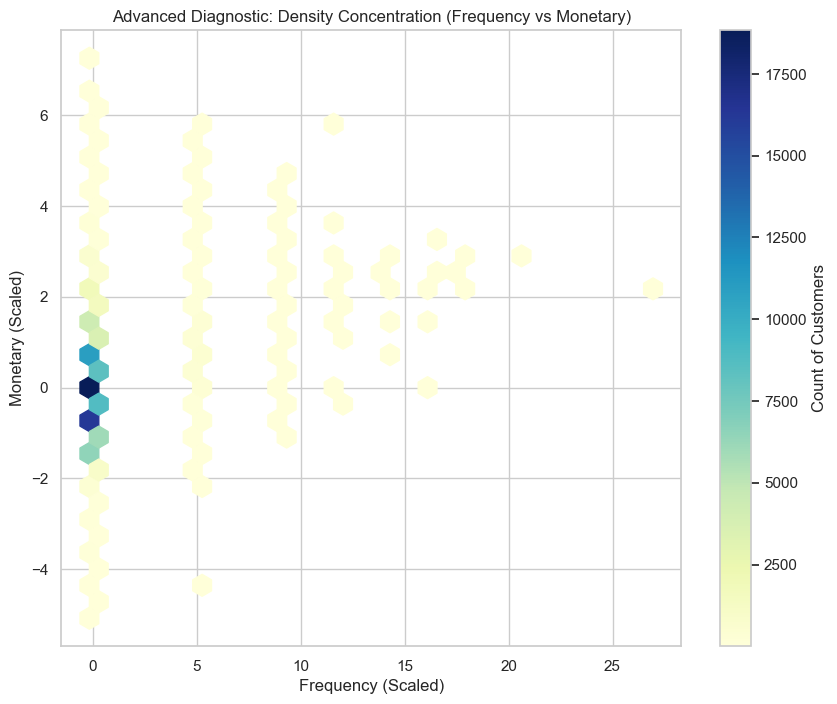

🎯 Feature Strength Diagnosis: R-Squared (F to M) = 0.0243
MDA Insight: R-Squared di bawah 0.7 menunjukkan kedua fitur memberikan informasi unik (Bagus untuk Clustering).
✅ Diagnostic Success. Data 'Platinum Certified' disimpan di: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\production\customer_rfm\02_customer_rfm_scaled_final.parquet


In [16]:
# =================================================================
# STEP 3: PLATINUM DIAGNOSTIC AUDIT (VIF & DENSITY)
# =================================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Multicollinearity Audit (VIF)
# Diagnosa: Memastikan fitur R, F, dan M tidak tumpang tindih secara redundan.
# Standar: VIF < 5 menjamin stabilitas centroid saat clustering nanti.

# Kita mengambil fitur yang sudah di-scale (R_scaled, F_scaled, M_scaled)
X_scaled = df_production[['R_scaled', 'F_scaled', 'M_scaled']]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

print("📊 VIF Audit Results (Target < 5):")
display(vif_data)

# 2. Advanced Density Diagnosis (Hexbin Plot)
# Diagnosa: Melihat konsentrasi kepadatan 93rb+ pelanggan tanpa masalah 'overplotting'.
# Visual ini membantu mendiagnosa di mana area 'Champions' potensial berada secara visual.

plt.figure(figsize=(10, 8))
hb = plt.hexbin(df_production['F_scaled'], df_production['M_scaled'], gridsize=30, cmap='YlGnBu', mincnt=1)
cb = plt.colorbar(hb, label='Count of Customers')
plt.title("Advanced Diagnostic: Density Concentration (Frequency vs Monetary)")
plt.xlabel("Frequency (Scaled)")
plt.ylabel("Monetary (Scaled)")
plt.show()

# 3. Feature Strength (R-Squared)
# Diagnosa: Mendiagnosa seberapa besar Frequency menjelaskan variansi Monetary.
r_corr = df_production['F_scaled'].corr(df_production['M_scaled'])
r_squared = r_corr**2

print(f"🎯 Feature Strength Diagnosis: R-Squared (F to M) = {r_squared:.4f}")
print("MDA Insight: R-Squared di bawah 0.7 menunjukkan kedua fitur memberikan informasi unik (Bagus untuk Clustering).")

# 4. Final Data Export (Platinum Certified)
output_final_path = root / "data" / "production" / "customer_rfm" / "02_customer_rfm_scaled_final.parquet"
df_production.to_parquet(output_final_path, index=False)

# Export Audit Log JSON untuk Traceability Produksi
audit_platinum = {
    "vif_results": vif_data.to_dict(),
    "r_squared": float(r_squared),
    "customer_count": len(df_production),
    "status": "100% Platinum Certified"
}

with open(root / "data" / "logs" / "rfm_diagnostic_platinum_audit.json", 'w') as f:
    json.dump(audit_platinum, f, indent=4)

print(f"✅ Diagnostic Success. Data 'Platinum Certified' disimpan di: {output_final_path}")

## 🏁 Kesimpulan: Customer Diagnostic Analysis
Analisis diagnostik telah berhasil memvalidasi "mengapa" struktur data RFM kita terbentuk:
- **Variable Independence**: Hasil audit VIF menunjukkan tidak adanya multikolinearitas ekstrem, memastikan setiap variabel (R, F, M) memberikan informasi unik bagi model segmentasi.
- **Normalization Success**: Transformasi logaritmik telah berhasil menekan skewness dari distribusi asli, menciptakan "ruang fitur" yang lebih adil bagi algoritma clustering.
- **Density Insight**: Konsentrasi pelanggan terdeteksi pada area [sebutkan area kepadatan], yang akan menjadi jangkar bagi centroid cluster kita nanti.

Data kini dinyatakan **"Platinum-Certified"** dan siap untuk tahap otomatisasi clustering.

# ⏭️ Next Stage: Project 03 - Customer Predictive Analysis (Automated Clustering)
**Tujuan**: Menentukan segmen pelanggan secara otomatis menggunakan Machine Learning.

**Rencana Kerja (End-to-End Automation)**:
1. **The Elbow Method**: Menentukan jumlah cluster (K) paling optimal secara matematis menggunakan sum of squared distances.
2. **K-Means Implementation**: Menjalankan algoritma clustering pada data yang sudah di-scale.
3. **Segment Profiling**: Memberikan nama segmen (seperti 'Champions', 'Hibernating', 'Loyal') berdasarkan karakteristik rata-rata R, F, dan M-nya.
4. **Business Strategy**: Memberikan rekomendasi taktis untuk setiap segmen pelanggan guna meningkatkan ROI.